In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

sns.set() 

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12, 6 
plt.rcParams['font.size'] = 14 
plt.rcParams['axes.unicode_minus'] = False 

# 결측치 시각화를 위한 라이브러리
import missingno 

# 데이터 전처리 알고리즘 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler 

# 학습용과 검증용으로 나누는  함수 
from sklearn.model_selection import train_test_split 

# 교차검증 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한도구 
from sklearn.model_selection import GridSearchCV 

# 머신러닝 알고리즘 - 분류 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from lightgbm import LGBMClassifier 
from xgboost import XGBClassifier 
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀 
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso 
from sklearn.linear_model import ElasticNet 
from sklearn.svm import SVR 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor 
from sklearn.ensemble import GradientBoostingRegressor 
from lightgbm import LGBMRegressor 
from xgboost import XGBRegressor 
from sklearn.ensemble import VotingRegressor 

# 학습 모델 저장을 위한 라이브러리
import pickle 

In [ ]:
train_df = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\파생변수 추가한 데이터\파생변수추가_전체_train.parquet")
test_df = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\파생변수 추가한 데이터\파생변수추가_전체_test.parquet")
target_df = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\PCA안한데이터\Segment_7월.csv")

In [54]:
train_df

,정상청구원금_B5M,연속유실적개월수_기본_24M_카드,이용금액_R3M_신용체크,이용금액_R3M_신용,이용카드수_신용체크,보유여부_해외겸용_본인,이용금액_오프라인_B0M,이용건수_신용_R12M,연체입금원금_B5M,이용건수_일시불_R6M,이용금액_일시불_R12M,이용금액대,이용카드수_신용,최대이용금액_일시불_R12M,이용금액_일시불_R6M,정상청구원금_B2M,이용건수_신판_R6M,상향가능한도금액,소지카드수_유효_신용,수신거부여부_메일
0,14958,13,196,196,1,0,4043,165,5752,64,20667,3,1,4906,8380,16524,67,0,1,0
1,3367,12,13475,13475,1,0,3980,204,821,81,54341,5,1,10407,19426,2420,81,4,1,0
2,23963,8,23988,23988,1,1,4524,148,7014,54,55656,3,1,10112,35136,21826,56,0,1,0
3,19614,5,3904,3904,1,1,3975,105,11196,26,10753,3,1,3075,-7031,19172,32,0,2,0
4,0,0,1190,0,1,1,0,-1,0,-2,-2129,0,0,62,957,272,-2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,579,0,2091,0,1,1,0,0,579,0,0,0,0,0,0,0,0,3,1,0
399996,30348,20,55111,55111,1,1,12312,292,0,137,207754,3,1,36896,99067,20929,137,12,1,0
399997,11489,24,14172,14172,1,1,9739,150,6360,54,37349,2,1,6846,16136,8746,58,0,1,1
399998,672,0,0,0,0,0,0,0,672,-2,0,0,0,0,0,467,-2,3,1,1


In [53]:
test_df

,기준년월,ID,소지카드수_이용가능_신용,소지카드수_유효_신용,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,수신거부여부_메일,수신거부여부_DM,이용금액_R3M_신용체크,...,청구금액_R3M,청구금액_B0,할인건수_R3M,월중평잔_일시불_B0M,월중평잔_일시불,평잔_일시불_3M,잔액_일시불_B0M,잔액_일시불_B1M,잔액_일시불_B2M,인입횟수_ARS_R6M
0,201807,TRAIN_000000,1,1,0,0,0,0,0,196,...,46588,12226,1회 이상,1084,1503,1791,998,736,1083,10회 이상
1,201807,TRAIN_000001,1,1,0,0,0,0,0,13475,...,10530,5834,1회 이상,4090,4447,3761,2565,6795,1424,1회 이상
2,201807,TRAIN_000002,1,1,1,1,0,0,0,23988,...,85931,21866,1회 이상,5006,5540,6796,5312,5150,6143,1회 이상
3,201807,TRAIN_000003,2,2,1,1,0,0,0,3904,...,61518,16356,1회 이상,487,606,772,730,462,708,10회 이상
4,201807,TRAIN_000004,1,1,1,1,0,0,0,1190,...,0,0,1회 이상,0,0,0,0,0,0,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,201807,TRAIN_399995,1,1,1,1,0,0,0,2091,...,0,0,1회 이상,0,0,0,0,0,0,1회 이상
399996,201807,TRAIN_399996,1,1,1,1,0,0,0,55111,...,79682,28825,1회 이상,10598,11321,11554,6374,12113,6533,1회 이상
399997,201807,TRAIN_399997,1,1,1,1,1,1,1,14172,...,15577,3911,1회 이상,1831,2144,2407,2168,845,1743,1회 이상
399998,201807,TRAIN_399998,1,1,0,0,1,1,1,0,...,0,0,1회 이상,0,0,0,0,0,0,1회 이상


In [33]:
train_df.select_dtypes(include='object').columns
obj_cols = train_df.select_dtypes(include='object').columns
obj_cols = obj_cols.drop('ID')
obj_cols


Index(['이용금액대', '할인건수_R3M', '인입횟수_ARS_R6M'], dtype='object')

In [34]:
train_df.drop(['Segment'], axis=1, inplace=True)

KeyError: "['Segment'] not found in axis"

In [36]:
# 순서에 따라 직접 매핑
train_df['이용금액대'] = train_df['이용금액대'].map({
    '09.미사용': 0,
    '05.10만원-': 1,
    '02.50만원+': 2,
    '01.100만원+': 3,
    '04.10만원+': 4,
    '03.30만원+': 5
})

train_df['할인건수_R3M'] = train_df['할인건수_R3M'].map({
    '1회 이상': 0,
    '10회 이상': 1,
    '20회 이상': 2,
    '30회 이상': 3,
    '40회 이상': 4
})

train_df['인입횟수_ARS_R6M'] = train_df['인입횟수_ARS_R6M'].map({
    '1회 이상': 1,
    '10회 이상': 2
})

In [37]:
train_df.drop(['기준년월'], axis=1, inplace=True)

In [38]:
train_df.drop(['ID'], axis=1, inplace=True)

In [39]:
# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(train_df)

,copy,True
,with_mean,True
,with_std,True


In [40]:
target_df

,기준년월,ID,Segment
0,201807,TRAIN_000000,D
1,201807,TRAIN_000001,E
2,201807,TRAIN_000002,C
3,201807,TRAIN_000003,D
4,201807,TRAIN_000004,E
...,...,...,...
399995,201807,TRAIN_399995,E
399996,201807,TRAIN_399996,D
399997,201807,TRAIN_399997,C
399998,201807,TRAIN_399998,E


In [41]:
# 인코딩 
encoder1 = LabelEncoder()
Seg = encoder1.fit_transform(target_df['Segment'])

In [42]:
# 입력과 결과로 나눈다.
X = train_df 
y = Seg

In [43]:
train_X = X
train_y = y

In [44]:
test_X = test_df

In [45]:
print(np.unique(train_y))

[0 1 2 3 4]


In [46]:
# 모델 학습
model = XGBClassifier(random_state=42, use_label_encoder=False, n_jobs=-1, eval_metric='mlogloss')
model.fit(X, y)

# 중요도 추출
importances = model.feature_importances_

# 정리해서 보기 좋게 출력
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(importance_df)

               feature  importance
17          정상청구원금_B5M    0.278631
63  연속유실적개월수_기본_24M_카드    0.073065
7        이용금액_R3M_신용체크    0.040015
8          이용금액_R3M_신용    0.032625
10          이용카드수_신용체크    0.031695
..                 ...         ...
30         _3순위업종_이용금액    0.002977
62       _1순위쇼핑업종_이용금액    0.002793
58        이용금액_온라인_B0M    0.002658
38       _3순위쇼핑업종_이용금액    0.002497
33       _2순위쇼핑업종_이용금액    0.002250

[76 rows x 2 columns]


In [48]:
# 1. Top 20 feature만 선택
top_n = 20
selected_features = importance_df.sort_values(by='importance', ascending=False).head(top_n)['feature'].tolist()

# 3. 모델 정의 및 학습
model.fit(X, y)

# 4. Top 20 feature 출력용 DataFrame
top20_df = importance_df.sort_values(by='importance', ascending=False).head(top_n)
print(top20_df)


               feature  importance
17          정상청구원금_B5M    0.278631
63  연속유실적개월수_기본_24M_카드    0.073065
7        이용금액_R3M_신용체크    0.040015
8          이용금액_R3M_신용    0.032625
10          이용카드수_신용체크    0.031695
3         보유여부_해외겸용_본인    0.025749
22       이용금액_오프라인_B0M    0.023947
32        이용건수_신용_R12M    0.022439
59          연체입금원금_B5M    0.019508
50        이용건수_일시불_R6M    0.018666
20       이용금액_일시불_R12M    0.018622
64               이용금액대    0.017862
14            이용카드수_신용    0.017653
34     최대이용금액_일시불_R12M    0.014788
23        이용금액_일시불_R6M    0.014756
19          정상청구원금_B2M    0.013691
47         이용건수_신판_R6M    0.013068
15            상향가능한도금액    0.012898
1          소지카드수_유효_신용    0.011745
5            수신거부여부_메일    0.010223


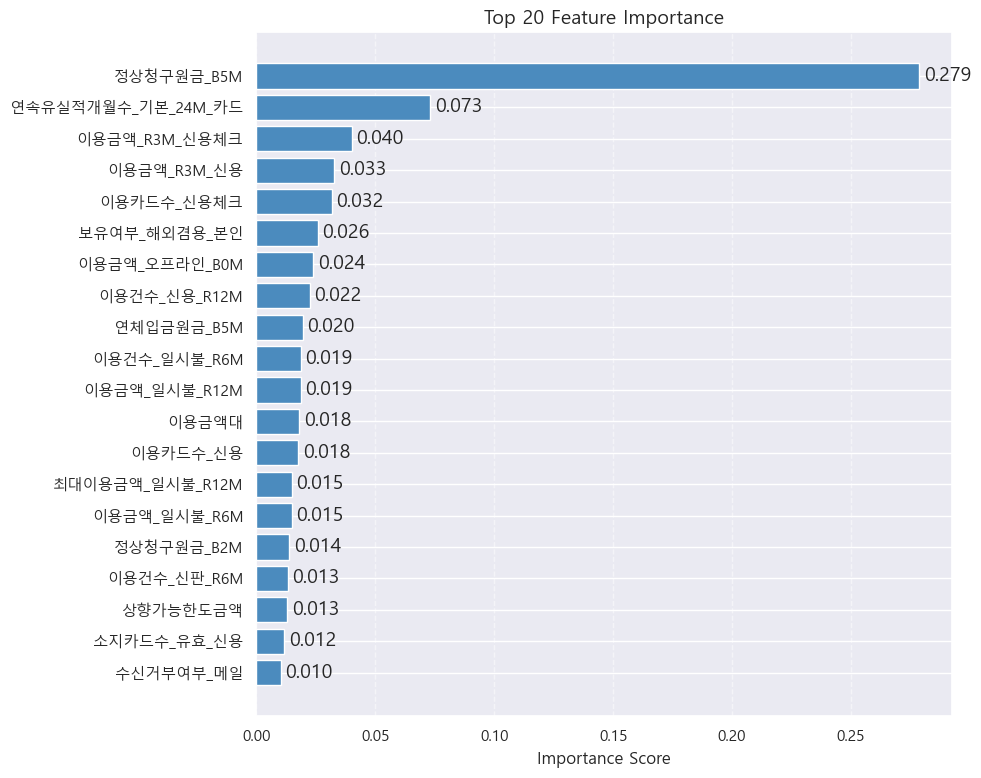

In [49]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화
plt.figure(figsize=(10, 8))
bars = plt.barh(top20_df['feature'][::-1], top20_df['importance'][::-1], color='#4B8BBE')  # 파란색 톤

# 각 바 옆에 숫자 표시
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')

plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Feature Importance', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [50]:
train_df = train_df[selected_features]
train_df

,정상청구원금_B5M,연속유실적개월수_기본_24M_카드,이용금액_R3M_신용체크,이용금액_R3M_신용,이용카드수_신용체크,보유여부_해외겸용_본인,이용금액_오프라인_B0M,이용건수_신용_R12M,연체입금원금_B5M,이용건수_일시불_R6M,이용금액_일시불_R12M,이용금액대,이용카드수_신용,최대이용금액_일시불_R12M,이용금액_일시불_R6M,정상청구원금_B2M,이용건수_신판_R6M,상향가능한도금액,소지카드수_유효_신용,수신거부여부_메일
0,14958,13,196,196,1,0,4043,165,5752,64,20667,3,1,4906,8380,16524,67,0,1,0
1,3367,12,13475,13475,1,0,3980,204,821,81,54341,5,1,10407,19426,2420,81,4,1,0
2,23963,8,23988,23988,1,1,4524,148,7014,54,55656,3,1,10112,35136,21826,56,0,1,0
3,19614,5,3904,3904,1,1,3975,105,11196,26,10753,3,1,3075,-7031,19172,32,0,2,0
4,0,0,1190,0,1,1,0,-1,0,-2,-2129,0,0,62,957,272,-2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,579,0,2091,0,1,1,0,0,579,0,0,0,0,0,0,0,0,3,1,0
399996,30348,20,55111,55111,1,1,12312,292,0,137,207754,3,1,36896,99067,20929,137,12,1,0
399997,11489,24,14172,14172,1,1,9739,150,6360,54,37349,2,1,6846,16136,8746,58,0,1,1
399998,672,0,0,0,0,0,0,0,672,-2,0,0,0,0,0,467,-2,3,1,1


In [51]:
train_df.to_parquet("C:/Users/SAMSUNG/OneDrive/바탕 화면/Feature Importance/파생변수포함_Top20_7월_train.parquet")

Test 변환하기

In [52]:
test_df.select_dtypes(include='object').columns
obj_cols = test_df.select_dtypes(include='object').columns
obj_cols = obj_cols.drop('ID')
obj_cols

Index(['이용금액대', '할인건수_R3M', '인입횟수_ARS_R6M'], dtype='object')

In [21]:
# 순서에 따라 직접 매핑
test_df['이용금액대'] = test_df['이용금액대'].map({
    '09.미사용': 0,
    '05.10만원-': 1,
    '02.50만원+': 2,
    '01.100만원+': 3,
    '04.10만원+': 4,
    '03.30만원+': 5
})

test_df['할인건수_R3M'] = test_df['할인건수_R3M'].map({
    '1회 이상': 0,
    '10회 이상': 1,
    '20회 이상': 2,
    '30회 이상': 3,
    '40회 이상': 4
})

test_df['인입횟수_ARS_R6M'] = test_df['인입횟수_ARS_R6M'].map({
    '1회 이상': 1,
    '10회 이상': 2
})

In [22]:
test_df

,기준년월,ID,소지카드수_이용가능_신용,소지카드수_유효_신용,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,수신거부여부_메일,수신거부여부_DM,이용금액_R3M_신용체크,...,소비집중도_신용,온라인비중,쇼핑업종총합,업종이용금액총합,정상청구원금_증감,일시불잔액_증감,가맹점_카드당비율,한도대비이용,수신거부합계,페이사용여부
0,201807,TEST_00000,1,1,1,1,1,1,1,21458,...,0.417891,0.064767,2890,8627,4483,4802,21.499893,3.065424e+03,3,1
1,201807,TEST_00001,1,1,1,1,0,0,0,18681,...,-0.235748,0.296823,6650,10997,4371,657,9.999950,1.868100e+09,0,1
2,201807,TEST_00002,1,1,0,0,0,0,0,40758,...,0.345534,0.000000,3951,17545,153,-50,39.499803,4.075800e+09,0,0
3,201807,TEST_00003,2,2,1,1,0,0,0,5255,...,0.359790,0.000000,2262,5483,303,-267,22.999770,1.751661e+03,0,0
4,201807,TEST_00004,1,1,1,1,1,1,1,16148,...,0.284189,0.000000,2424,5857,2333,17,9.333302,8.073960e+03,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,201812,TEST_99995,1,1,0,0,0,0,0,0,...,0.000000,0.000000,0,0,0,0,0.000000,0.000000e+00,0,0
599996,201812,TEST_99996,1,1,0,0,0,0,0,3110,...,-0.250095,0.000000,0,972,-3531,-47,2.999970,3.887495e+02,0,0
599997,201812,TEST_99997,2,2,0,0,0,0,0,0,...,0.000000,0.000000,0,0,-186,0,200000.000000,0.000000e+00,0,0
599998,201812,TEST_99998,1,1,1,1,1,1,1,173263,...,0.157490,0.328299,54247,85111,3047,3330,16.999972,1.925142e+04,3,1


In [23]:
test_df.drop(['기준년월'], axis=1, inplace=True)

In [24]:
test_df.drop(['ID'], axis=1, inplace=True)

In [25]:
# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(test_df)

,copy,True
,with_mean,True
,with_std,True


In [26]:
X_test = test_df[selected_features]

In [28]:
X_test.to_parquet("C:/Users/SAMSUNG/OneDrive/바탕 화면/Feature Importance/파생변수포함_Top20_전체_test.parquet")

예측하기